In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

target_label_data = pd.read_pickle("/content/drive/MyDrive/Project_Work/data/interim_data/target_label_data.pkl")

scan_reports_data = pd.read_csv("/content/drive/MyDrive/Project_Work/data/raw_data/scan_reports_data.csv")
scan_reports_data = scan_reports_data.drop(columns=['Unnamed: 0']).reset_index(drop=True)

modelling_data = pd.merge(
    scan_reports_data,
    target_label_data,
    how="inner",
    on="CUSTOMER_ID"
)

# temp
cnt_columns = [i for i in modelling_data.columns if "COUNT" in i]
modelling_data[cnt_columns] = modelling_data[cnt_columns].round()

### SAMPLE ROWS

In [ ]:
modelling_data[modelling_data['IS_PRETERM_FLAG'] == 1]

,CUSTOMER_ID,ABDOMINAL_CIRCUMFERENCE__T2_AVG,ABDOMINAL_CIRCUMFERENCE__T2_MAX,ABDOMINAL_CIRCUMFERENCE__T3_AVG,ABDOMINAL_CIRCUMFERENCE__T3_MAX,AFI_VALUE__T2_AVG,AFI_VALUE__T2_MAX,AFI_VALUE__T3_AVG,AFI_VALUE__T3_MAX,BIPARIETAL_DIAMETER__T2_AVG,...,SDP__T2_AVG,SDP__T2_MAX,SDP__T3_AVG,SDP__T3_MAX,TCD__T2_AVG,TCD__T2_MAX,TCD__T3_AVG,TCD__T3_MAX,AGE,IS_PRETERM_FLAG
82,1000000100513619,149.031322,164.844167,423.010811,442.982420,18.012434,18.012434,39.102548,41.835881,59.552822,...,5.087161,5.187161,6.559184,6.609184,32.459228,34.009228,40.011031,40.225710,35.13,1
111,1000000100526478,94.435700,94.435700,57.900000,57.900000,8.159016,8.159016,2.200000,2.200000,14.000000,...,2.476633,2.490389,1.000000,1.000000,1.800000,1.800000,18.000000,18.000000,26.66,1
178,1000000100553287,155.716335,159.405887,57.900000,57.900000,12.319347,12.319347,2.200000,2.200000,27.936849,...,4.070097,4.070097,3.316372,3.316372,4.240584,4.240584,24.481264,24.481264,38.11,1
218,1000000100577359,141.474306,149.311889,287.221295,291.844092,15.149706,15.149706,21.709754,24.209754,42.424433,...,4.162280,4.262280,4.494526,4.519526,24.693567,25.468567,36.003212,36.074755,34.82,1
471,1000000100653119,94.994783,138.855275,183.037528,183.430061,12.787958,12.787958,7.513211,8.313211,31.021645,...,5.999253,5.999253,3.884310,4.134310,16.302527,16.302527,26.450220,26.450220,38.92,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7065,1000000101268952,265.000000,267.500000,513.353789,533.676047,22.323556,22.323556,52.105788,52.605788,99.235460,...,7.302226,7.302226,5.095853,5.095853,39.678571,39.678571,38.716189,38.987367,37.36,1
7093,1000000101291777,134.978126,145.341844,168.598453,168.598453,13.031620,13.031620,7.932628,7.932628,40.608204,...,4.050859,4.064615,3.860113,4.082413,19.378854,19.475609,30.126741,30.126741,41.68,1
7103,1000000101305229,97.399149,121.211776,75.111023,75.111023,10.990162,10.990162,2.200000,2.200000,25.250265,...,3.718427,3.718427,3.141803,3.141803,46.784180,46.784180,28.876749,28.876749,32.81,1
7111,1000000101320436,138.218879,148.619524,229.735141,229.735141,13.415666,13.415666,9.917343,10.838640,42.352656,...,4.174935,4.188691,5.715763,5.715763,20.739261,20.836016,30.683607,30.683607,21.02,1


#### TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    modelling_data.drop(columns=["CUSTOMER_ID","IS_PRETERM_FLAG"]),
    modelling_data['IS_PRETERM_FLAG'],
    test_size=0.3,
    random_state=21
)

In [ ]:
pd.DataFrame({
    'Type': ['Train', 'Test'],
    'Population': [len(X_train), len(X_test)],
    'Premature Births':[sum(y_train), sum(y_test)]
}).assign(
    Rate = lambda x: round(x['Premature Births'] / x['Population'] * 100,2)
)

,Type,Population,Premature Births,Rate
0,Train,4979,97,1.95
1,Test,2135,44,2.06


### Feature Selection on Train Data

In [ ]:
from sklearn.feature_selection import mutual_info_classif

def calculate_information_gain(X, y):
    """
    Calculate information gain using mutual information.
    """
    # Compute mutual information between each feature and the target
    mutual_info = mutual_info_classif(X, y)

    # Return the mutual information scores
    return mutual_info

# Example usage:
# X is your feature matrix, y is your target variable
information_gain = calculate_information_gain(X_train, y_train)
info_gain_df = pd.DataFrame({
    "varaible": list(X_train.columns),
    "information_gain": information_gain
}).sort_values('information_gain', ascending=False)

In [ ]:
info_gain_df["information_gain"].quantile(0.95)

0.007245016761112975

In [ ]:
final_features = [
    "CRL__T3_AVG",
    "MEAN PI__T3_MAX",
    "ABDOMINAL_CIRCUMFERENCE__T2_MAX",
    "LEFT UTERINE__T3_MAX",
    "BIPARIETAL_DIAMETER__T2_AVG",
    "LIQUOR__T3_MAX",
    "ESTIMATED_FETAL_WEIGHT__T3_AVG",
    "CERVIX_LENGTH__T3_MAX",
    "SDP__T2_AVG",
    "PLACENTA__T3_MAX"
]

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix, f1_score, roc_curve, accuracy_score
import numpy as np

def get_metric_df(actuals, pred_scores, model_name):
    """
    """

    # selecting best cutoff
    fpr, tpr, thresholds = roc_curve(actuals, pred_scores)
    j_scores = tpr - fpr
    best_cutoff = thresholds[np.argmax(j_scores)]

    # Accuracy
    accuracy = accuracy_score(y_true=actuals, y_pred=[1 if pred > best_cutoff else 0 for pred in pred_scores])

    # AUC
    auc_roc = roc_auc_score(actuals, pred_scores)

    # Precision
    precision = precision_score(actuals, [1 if pred > best_cutoff else 0 for pred in pred_scores])

    # Recall
    recall = recall_score(actuals, [1 if pred > best_cutoff else 0 for pred in pred_scores])

    # F1 Score
    f1 = f1_score(actuals, [1 if pred > best_cutoff else 0 for pred in pred_scores])

    # Specificity
    tn, fp, fn, tp = confusion_matrix(actuals, [1 if pred > best_cutoff else 0 for pred in pred_scores]).ravel()
    specificity = tn / (tn+fp)

    conf_matrix = confusion_matrix(actuals, y_pred = [1 if pred > best_cutoff else 0 for pred in pred_scores])

    return({
        "model":model_name,
        "accuracy":round(accuracy,5),
        'cutoff_prob': round(best_cutoff,5),
        "auc":round(auc_roc,4),
        'precision': round(precision,4),
        'specificity': round(specificity,4),
        "recall":round(recall,4),
        "f1": round(f1,4),
        "conf_matrix": conf_matrix
    })


### Logistic Regression

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the robust scaler
scaler = RobustScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train[final_features])

# Transform the testing data using the fitted scaler
X_test_scaled = scaler.transform(X_test[final_features])

# Initialize the logistic regression model
log_reg = LogisticRegression(penalty='l1',solver='liblinear', C=0.1)

# Train the logistic regression model on the scaled training data
log_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled testing data
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:,1]

logreg_metrics = get_metric_df(
    actuals=y_test,
    pred_scores=y_pred_prob,
    model_name="logistc_regression"
)

logreg_metrics

{'model': 'logistc_regression',
 'accuracy': 0.76815,
 'cutoff_prob': 0.02183,
 'auc': 0.9125,
 'precision': 0.0753,
 'specificity': 0.7652,
 'recall': 0.9091,
 'f1': 0.1391,
 'conf_matrix': array([[1600,  491],
        [   4,   40]])}

### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Naive Bayes classifier (Gaussian Naive Bayes for continuous features)
nb_classifier = GaussianNB()

# Train the Naive Bayes classifier on the training data
nb_classifier.fit(X_train[final_features], y_train)

# Make predictions on the testing data
y_pred_prob = nb_classifier.predict_proba(X_test[final_features])[:,1]

naive_bayes_metrics = get_metric_df(
    actuals=y_test,
    pred_scores=y_pred_prob,
    model_name="naive_bayes"
)

naive_bayes_metrics


{'model': 'naive_bayes',
 'accuracy': 0.67119,
 'cutoff_prob': 0.00838,
 'auc': 0.7912,
 'precision': 0.0481,
 'specificity': 0.6686,
 'recall': 0.7955,
 'f1': 0.0907,
 'conf_matrix': array([[1398,  693],
        [   9,   35]])}

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=500, random_state=42, criterion="entropy", n_jobs=3)  # You can adjust the number of estimators as needed

# Train the Random Forest classifier on the training data
rf_classifier.fit(X_train[final_features], y_train)

# Make predictions on the testing data
y_pred_prob = rf_classifier.predict_proba(X_test[final_features])[:,1]

rf_metrics = get_metric_df(
    actuals=y_test,
    pred_scores=y_pred_prob,
    model_name="random_forest"
)
rf_metrics

{'model': 'random_forest',
 'accuracy': 0.95878,
 'cutoff_prob': 0.062,
 'auc': 0.9857,
 'precision': 0.3254,
 'specificity': 0.9593,
 'recall': 0.9318,
 'f1': 0.4824,
 'conf_matrix': array([[2006,   85],
        [   3,   41]])}

### XG Boost

In [ ]:
import xgboost as xgb

# Initialize the XGBoost classifier


import xgboost as xgb

# Create regression matrices
train_xgb = xgb.DMatrix(X_train[final_features], y_train)
test_xgb = xgb.DMatrix(X_test[final_features], y_test)

# Train the XGBoost classifier on the training data
n=1000
params = {
    'objective': 'binary:logistic',
    'max_depth': 4,
    'learning_rate': 0.05,
}
model = xgb.train(params=params,dtrain=train_xgb,num_boost_round=n)

# Make predictions on the testing data
y_pred_prob = model.predict(test_xgb)

xgb_metrics = get_metric_df(
    actuals=y_test,
    pred_scores=y_pred_prob,
    model_name="xgb_classifier"
)

xgb_metrics

{'model': 'xgb_classifier',
 'accuracy': 0.94614,
 'cutoff_prob': 0.0035,
 'auc': 0.985,
 'precision': 0.268,
 'specificity': 0.9464,
 'recall': 0.9318,
 'f1': 0.4162,
 'conf_matrix': array([[1979,  112],
        [   3,   41]])}

### Stacked Emsemble Model

In [ ]:
!pip install h2o

import h2o
from h2o.automl import H2OAutoML
# Start the H2O cluster (locally)
h2o.init()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.6/265.6 MB 4.3 MB/s eta 0:00:00
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.22" 2024-01-16; OpenJDK Runtime Environment (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1); OpenJDK 64-Bit Server VM (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.10/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmppevglh7n
  JVM stdout: /tmp/tmppevglh7n/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmppevglh7n/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,06 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.1
H2O_cluster_version_age:,"14 days, 23 hours and 12 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_642m1n
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
train = pd.concat([X_train[final_features].reset_index(drop = True), y_train.reset_index(drop=True)],axis=1)
test = pd.concat([X_test[final_features].reset_index(drop = True), y_test.reset_index(drop=True)],axis=1)
x_vars = list(train.drop(columns=['IS_PRETERM_FLAG']).columns)
y_var = "IS_PRETERM_FLAG"

train = h2o.H2OFrame(train)
test = h2o.H2OFrame(test)

train[y_var] = train[y_var].asfactor()
test[y_var] = test[y_var].asfactor()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Run AutoML for 20 base models
aml = H2OAutoML(
    max_models=3,
    include_algos=["glm","gbm","drf","StackedEnsemble"],
    seed=25,
    verbosity="warn"
)

aml_summary = aml.train(
    training_frame=train,
    x = x_vars,
    y = y_var
)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
aml.leaderboard

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_BestOfFamily_1_AutoML_1_20240328_143446,0.976365,0.0402121,0.645294,0.198437,0.102903,0.010589
GBM_1_AutoML_1_20240328_143446,0.97514,0.043151,0.625654,0.208541,0.107148,0.0114807
DRF_1_AutoML_1_20240328_143446,0.960954,0.0656069,0.653684,0.173278,0.106915,0.0114308
GLM_1_AutoML_1_20240328_143446,0.902652,0.064672,0.316066,0.358026,0.124982,0.0156205


In [ ]:
def get_best_stacked_model(aml):
    lb = aml.leaderboard.as_data_frame()
    lb = lb[lb['model_id'].str.startswith("StackedEnsemble")].sort_values('auc', ascending=False).reset_index(drop=True)
    model_id = lb['model_id'][0]
    stacked_model = h2o.get_model(model_id=model_id)
    return stacked_model

In [ ]:
stacked_model = get_best_stacked_model(aml=aml)
y_pred_prob = stacked_model.predict(test).as_data_frame()['p1']

/usr/local/lib/python3.10/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install datatable (for Python 3.9 or lower), or polars and pyarrow (for Python 3.10 or above) and activate it using:

with h2o.utils.threading.local_context(polars_enabled=True, datatable_enabled=True):
    pandas_df = h2o_df.as_data_frame()

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.10/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install datatable (for Python 3.9 or lower), or polars and pyarrow (for Python 3.10 or above) and activate it using:

with h2o.utils.threading.local_context(polars_enabled=True, datatable_enabled=True):
    pandas_df = h2o_df.as_data_frame()

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
stacked_model_metrics = get_metric_df(
    actuals=y_test,
    pred_scores=y_pred_prob,
    model_name="stacked_model"
)
stacked_model_metrics

{'model': 'stacked_model',
 'accuracy': 0.92131,
 'cutoff_prob': 0.01934,
 'auc': 0.9874,
 'precision': 0.2019,
 'specificity': 0.9206,
 'recall': 0.9545,
 'f1': 0.3333,
 'conf_matrix': array([[1925,  166],
        [   2,   42]])}

In [ ]:
pd.DataFrame([
    logreg_metrics,
    naive_bayes_metrics,
    rf_metrics,
    xgb_metrics,
    stacked_model_metrics
])

,model,accuracy,cutoff_prob,auc,precision,specificity,recall,f1,conf_matrix
0,logistc_regression,0.76815,0.02183,0.9125,0.0753,0.7652,0.9091,0.1391,"[[1600, 491], [4, 40]]"
1,naive_bayes,0.67119,0.00838,0.7912,0.0481,0.6686,0.7955,0.0907,"[[1398, 693], [9, 35]]"
2,random_forest,0.95878,0.06200,0.9857,0.3254,0.9593,0.9318,0.4824,"[[2006, 85], [3, 41]]"
3,xgb_classifier,0.94614,0.00350,0.9850,0.2680,0.9464,0.9318,0.4162,"[[1979, 112], [3, 41]]"
4,stacked_model,0.92131,0.01934,0.9874,0.2019,0.9206,0.9545,0.3333,"[[1925, 166], [2, 42]]"


In [ ]:
!pip install MOBPY
from MOBPY.MOB import MOB

def _prepare_plot_data(X_train, y_train, var):
    """
    """
    df = pd.concat([X_train[[var]], y_train], axis=1)
    MOB_ALGO = MOB(
        data = df,
        var = var,
        response = 'IS_PRETERM_FLAG',
        exclude_value = None
    )

    # A must-do step to set the binning constraints.
    MOB_ALGO.setBinningConstraints(
        max_bins = 5,
        min_bins = 3,
        max_samples = 0.4,
        min_samples = 0.05,
        min_bads = 0.05,
        init_pvalue = 0.4,
        maximize_bins=True
    )

    # execute the MOB algorithm.
    StatsBinning = MOB_ALGO.runMOB(mergeMethod='Stats') # Run under the statistical base.
    StatsBinning['var_bin'] = [f"[{i} - {j})" for i,j in zip(
        [i if np.isinf(i) else round(i,3) for i in np.array(StatsBinning['[intervalStart'].values, dtype = "float")],
        [i if np.isinf(i) else round(i,3) for i in np.array(StatsBinning['intervalEnd)'].values, dtype = "float")])
    ]
    plot_data = StatsBinning[['var_bin','nsamples','bads','bad_rate']].copy()
    return plot_data

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def produce_monthly_churn_rate_plot(X_train, y_train, final_features):
    """
    """
    for var in final_features:
        plot_data = _prepare_plot_data(
            X_train=X_train,
            y_train=y_train,
            var=var
        )

        # Create figure with secondary y-axis
        fig = make_subplots(specs=[[{"secondary_y": True}]])
        fig.add_traces(
            go.Bar(
                x=plot_data['var_bin'],
                y=plot_data['nsamples'],
                name=var,
                marker=dict(color='#a9dbf5'),
            )
        )

        fig.add_trace(
            go.Scatter(
                x=plot_data['var_bin'],
                y=plot_data['bad_rate'],
                text=plot_data['bad_rate'].apply(lambda x: f"{round(x * 100,2)}%"),
                textposition='top center',
                textfont=dict(color='red'),
                name="Preterm Rate",
                mode="markers+lines+text",
                marker=dict(color="red")
            ),
            secondary_y=True,
        )

        fig.update_layout(
            xaxis=dict(showgrid=False),
            yaxis=dict(showgrid=False),
            yaxis2=dict(tickformat=",.0%"),
            font_family="Trebuchet MS",
            title_font_family="Sans-serif",
            legend_title_text="",
            title_text=f"<b>{var.upper()}</b>",
            width=1200,
            height=500
        )

        fig.show()

    return None

In [ ]:
produce_monthly_churn_rate_plot(
    X_train=X_train,
    y_train=y_train,
    final_features=final_features
)

In [ ]:
feature_importance = pd.DataFrame(model.get_score(importance_type="total_gain"), index=[0]).T.reset_index().rename(
    columns={'index':'variable', 0:'importance'}
).sort_values('importance').assign(
    relative_importance = lambda x: (x['importance'] / sum(x['importance'])).round(4)
)

In [ ]:
import plotly.express as px
fig = px.bar(
        feature_importance,
        y="variable",
        x="relative_importance",
        text="relative_importance",
        color_discrete_sequence=['#88CCFC'] * len(feature_importance),
        width=1000,
        height=500,
        orientation="h"
    )
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

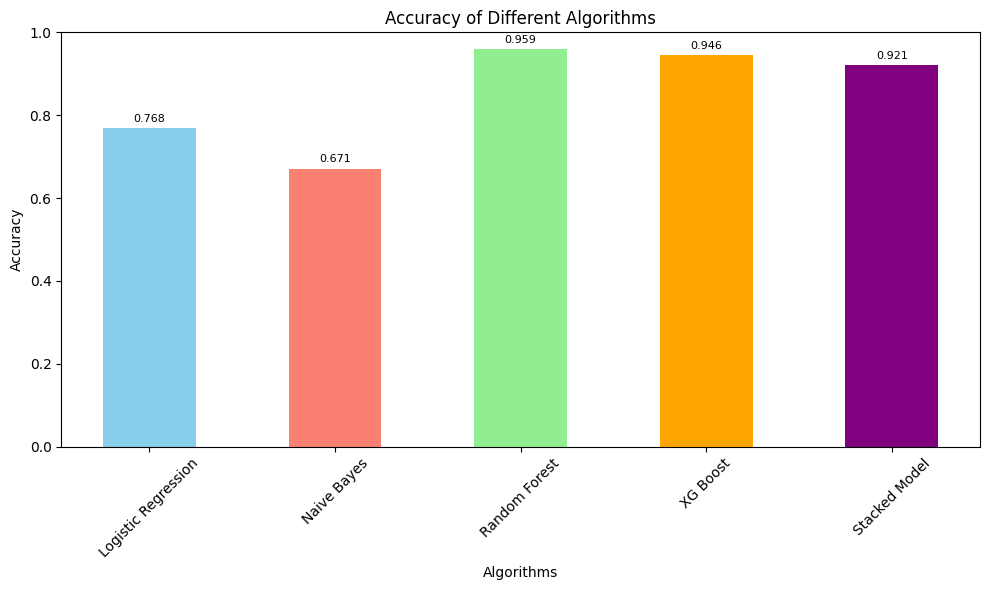

In [ ]:
import matplotlib.pyplot as plt

performance_metrics = {
    'Logistic Regression': 0.76815,
    'Naive Bayes': 0.67119,
    'Random Forest': 0.95878,
    'XG Boost':0.94614,
    'Stacked Model':0.92131
}
algorithms = list(performance_metrics.keys())
metrics = list(performance_metrics.values())
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'purple']

plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms, metrics, color=colors[:len(algorithms)], width=0.5)
plt.xlabel('Algorithms')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Algorithms')
plt.ylim(0, 1)
plt.xticks(rotation=45)

for bar, metric in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{metric:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()  # Adjust layout
plt.show()